# Digit dataset

Exploring first time a data set with intrument of machine learning. Familiarize with it.

In [16]:
from sklearn import datasets

digits = datasets.load_digits()

In [17]:
from sklearn.manifold import Isomap

embedding = Isomap(n_components=2, n_neighbors=5)
x = embedding.fit_transform(digits.data)

/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/opt/anaconda3/envs/astrostats/lib/python3.11/site-packages/scipy/sparse/_index.py:102: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


/var/folders/y3/hmkzfhj13553n22ygq7syz5r0000gn/T/ipykernel_58554/1213278217.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(x[:, 0], x[:, 1], c=digits.target, cmap=plt.cm.get_cmap('Spectral', 10))


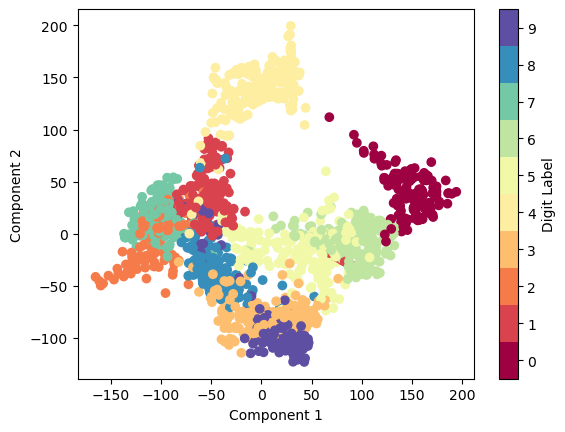

In [18]:
import matplotlib.pyplot as plt

plt.scatter(x[:, 0], x[:, 1], c=digits.target, cmap=plt.cm.get_cmap('Spectral', 10))
plt.colorbar(ticks=range(10), label='Digit Label')
plt.clim(-0.5, 9.5)
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# Split the data into training and testing sets 
x_train, x_test, y_train, y_test = train_test_split(x, digits.target, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=10000, solver='sag')
lr.fit(x_train, y_train)

LogisticRegression(max_iter=10000, solver='sag')

In [20]:
from sklearn.metrics import confusion_matrix

# Predict on train set
y_pred = lr.predict(x_train)
cm = confusion_matrix(y_train, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[140   0   0   0   1   0   4   0   0   0]
 [  0 113   2   0   4   1  21   9   4   0]
 [  0   4  63   0   0   0   0  73   4   0]
 [  0   0   0 104   0   5   0   0  15  25]
 [  0   5   1   0 129   0   0   0   0   0]
 [  1  11   0   3   0  90  27   0   3   0]
 [  7   7   0   0   0  15 117   0   0   0]
 [  0   2  56   0   0   0   0  83   4   0]
 [  0   3   4   5   0   1   0   0 128   3]
 [  0  10   4 110   0   0   0   7   7   2]]


In [21]:
from sklearn.metrics import accuracy_score

y_pred = lr.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 68.61%


In [22]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  5  2  0  0]
 [ 0  1 13  0  0  0  0 17  2  0]
 [ 0  0  0 25  0  1  0  0  4  4]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 1  7  0  1  0 29  8  0  1  0]
 [ 2  0  0  0  0  3 30  0  0  0]
 [ 0  1 11  0  0  0  0 21  1  0]
 [ 0  0  0  0  0  0  0  0 28  2]
 [ 0  3  1 32  0  0  0  3  0  1]]


Classification report (rows: labels + macro/weighted avg):
              precision    recall  f1-score     support
0              0.916667  1.000000  0.956522   33.000000
1              0.636364  0.750000  0.688525   28.000000
2              0.520000  0.393939  0.448276   33.000000
3              0.431034  0.735294  0.543478   34.000000
4              1.000000  1.000000  1.000000   46.000000
5              0.878788  0.617021  0.725000   47.000000
6              0.697674  0.857143  0.769231   35.000000
7              0.488372  0.617647  0.545455   34.000000
8              0.777778  0.933333  0.848485   30.000000
9              0.142857  0.025000  0.042553   40.000000
accuracy       0.686111  0.686111  0.686111    0.686111
macro avg      0.648953  0.692938  0.656752  360.000000
weighted avg   0.659048  0.686111  0.657821  360.000000


Text(50.722222222222214, 0.5, 'True Label')

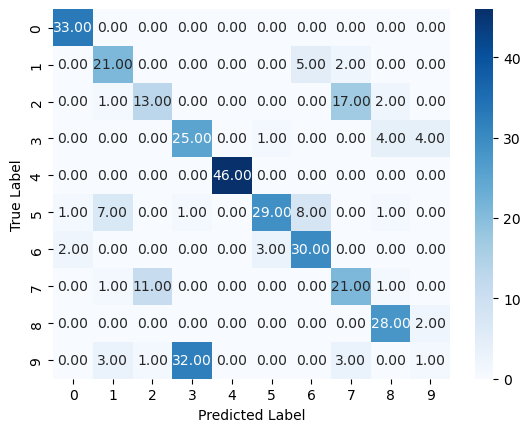

In [23]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True, target_names=[str(i) for i in range(10)])
df = pd.DataFrame(report).T
print('Classification report (rows: labels + macro/weighted avg):')
print(df)

sns.heatmap(cm, annot=True, cmap='Blues', fmt='.2f')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')